How to use this notebook:

1. Shot with VARYING LIGHT with same exposure time. The illumiance should be as uniform as possible. For EACH illuminance intensity, 30 frames is recommanded. 
   
2. The codes will first calculate the time-domain average and standard variation for EACH t and 2 single frames is obtained for EACH t. They are put into 2 arrays (*I_img_stack*; *sigma_img_stack*). Then the values are averaged in space-domain to become 2 value arrays (*I_stack*, *sigma_stack*). Note that only 25% pixels in the middle are used for further calculation.
   
3. **Offset** and **readout noise** (DN value) should be set manually. One may calculate by dark field tests. Be careful to pair the data with camera gain state correctly (HG/LG). 
   
4. After subtracting the offset, logDN-logDN curve is plotted. One should choose *min_value* and *max_value* manually for shot-noise-dominant region, which is then fitted to get **gain** (DN/e-). 
   
5. *actual_signal* and *actual_noise* could be saved as .npy. Once different gains are obtained, one could plot them with absolute units(e-) in one figure.

## Calculate PTC curve

In [7]:
import os
import numpy as np
import tifffile as tiff
from funcs import * 

In [8]:
names_bright = ['10us_'+str(num+1) for num in range(16)]+[str(num+1) for num in range(12)]
# names_bright = [str(num+1) for num in range(23)]
folder_path = '/Volumes/Virus/D7-Research Documents/Dhyana 401D Test/HG/Bright_' 
# folder_path = '/Volumes/Virus/D7-Research Documents/Dhyana 401D Test/LG/Bright_'

bright_paths = [(folder_path + name) for name in names_bright]

In [9]:
I_stack = []
sigma_stack = []
height, width = 2048, 2048
new_size = int(min(height, width) * np.sqrt(0.5))
start_y = (height - new_size) // 2
start_x = (width - new_size) // 2

new_size = int(min(height, width) * np.sqrt(0.5))
for name in bright_paths:
    print("Processing from: "+name)
    I_img, sigma_img = time_average_all_tif(name) 
    I_stack.append(np.mean(I_img[start_y:start_y+new_size, start_x:start_x+new_size]))
    sigma_stack.append(np.mean(sigma_img[start_y:start_y+new_size, start_x:start_x+new_size]))

Processing from: /Volumes/Virus/D7-Research Documents/Dhyana 401D Test/HG/Bright_10us_1
✅ 成功处理 30 张图像，共形状 (2048, 2048)
Processing from: /Volumes/Virus/D7-Research Documents/Dhyana 401D Test/HG/Bright_10us_2
✅ 成功处理 30 张图像，共形状 (2048, 2048)
Processing from: /Volumes/Virus/D7-Research Documents/Dhyana 401D Test/HG/Bright_10us_3
✅ 成功处理 30 张图像，共形状 (2048, 2048)
Processing from: /Volumes/Virus/D7-Research Documents/Dhyana 401D Test/HG/Bright_10us_4
✅ 成功处理 30 张图像，共形状 (2048, 2048)
Processing from: /Volumes/Virus/D7-Research Documents/Dhyana 401D Test/HG/Bright_10us_5
✅ 成功处理 30 张图像，共形状 (2048, 2048)
Processing from: /Volumes/Virus/D7-Research Documents/Dhyana 401D Test/HG/Bright_10us_6
✅ 成功处理 30 张图像，共形状 (2048, 2048)
Processing from: /Volumes/Virus/D7-Research Documents/Dhyana 401D Test/HG/Bright_10us_7
✅ 成功处理 30 张图像，共形状 (2048, 2048)
Processing from: /Volumes/Virus/D7-Research Documents/Dhyana 401D Test/HG/Bright_10us_8
✅ 成功处理 30 张图像，共形状 (2048, 2048)
Processing from: /Volumes/Virus/D7-Research Docu

In [10]:
import matplotlib.pyplot as plt
offset = 1893.68 # DN
readout_noise = 82.34 # DN

In [11]:
log_I_stack_trimmed = np.log10(np.array((I_stack[:])) - offset)
log_sigma_stack_trimmed = np.log10(np.array(sigma_stack[:]))

In [12]:
log_I_stack_trimmed

array([2.404797 , 2.403656 , 2.4472694, 2.6302764, 2.782317 , 2.970016 ,
       3.0012965, 3.1211982, 3.2928648, 3.4954212, 3.7606683, 2.1072655,
       2.2153842, 2.329207 , 2.4325209, 2.6783986, 3.8062747, 3.828711 ,
       3.930763 , 4.015391 , 4.099613 , 4.2287135, 4.4478707, 4.611381 ,
       4.742653 , 4.7732286, 4.8016953, 4.7573276], dtype=float32)

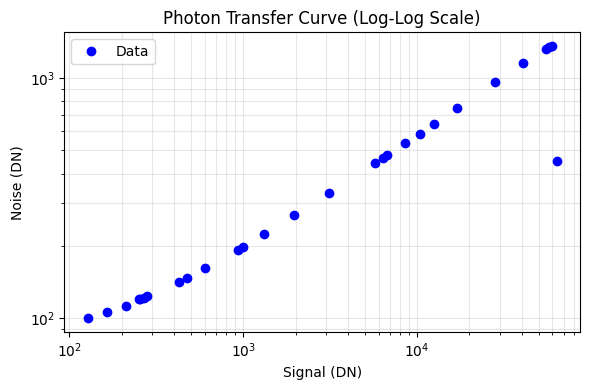

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))

actual_signal = 10 ** log_I_stack_trimmed
actual_noise = 10 ** log_sigma_stack_trimmed

# 使用对数坐标轴
plt.loglog(actual_signal, actual_noise, marker='o', linestyle='none', color='blue', label='Data')

# 标签与标题
plt.xlabel("Signal (DN)")
plt.ylabel("Noise (DN)")
plt.title("Photon Transfer Curve (Log-Log Scale)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
min_value = 5000
max_value = 40000
fixed_slope = 0.5
mask = (actual_signal >= min_value) & (actual_signal <= max_value)
x = log_I_stack_trimmed[mask]
y = log_sigma_stack_trimmed[mask]

固定斜率 a = 0.5
拟合得到截距 b = 0.762188
R^2 = 0.9995


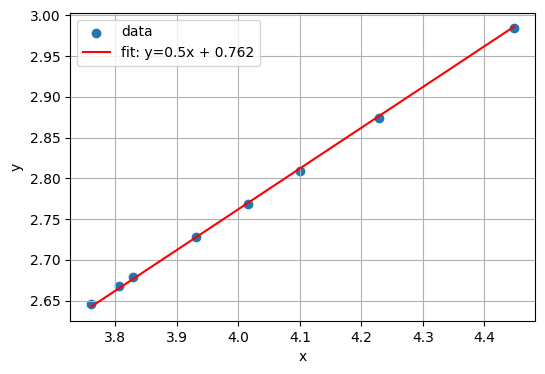

In [15]:
a_fixed = 0.5
b_fit = np.mean(y - a_fixed * x)
y_fit = a_fixed * x + b_fit
print(f"固定斜率 a = {a_fixed}")
print(f"拟合得到截距 b = {b_fit:.6g}")
resid = y - y_fit
ss_res = np.sum(resid**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot
print(f"R^2 = {r2:.4f}")
plt.figure(figsize=(6,4))
plt.scatter(x, y, label='data')
plt.plot(x, y_fit, 'r-', label=f'fit: y={a_fixed}x + {b_fit:.3f}')
plt.legend()
plt.xlabel('x'); plt.ylabel('y'); plt.grid(True)
plt.show()


In [16]:
gain = 10**(2 * b_fit)
readout_noise_e = readout_noise/gain
print("Gain of this camera is:"+str(gain)+" DN/e")
print("Readout noise of this camera is:"+str(readout_noise_e)+"e")

Gain of this camera is:33.44848042096352 DN/e
Readout noise of this camera is:2.4616962852636552e


In [17]:
np.save('Data/CameraTest/Dhyana401D/HG_I.npy', actual_signal)
np.save('Data/CameraTest/Dhyana401D/HG_sigma.npy', actual_noise)

In [18]:
gain_HG = 33.448
gain_LG = 1.4788
I_HG = np.load('Data/CameraTest/Dhyana401D/HG_I.npy')/gain_HG
I_LG = np.load('Data/CameraTest/Dhyana401D/LG_I.npy')/gain_LG
sigma_HG = np.load('Data/CameraTest/Dhyana401D/HG_sigma.npy')/gain_HG
sigma_LG = np.load('Data/CameraTest/Dhyana401D/LG_sigma.npy')/gain_LG

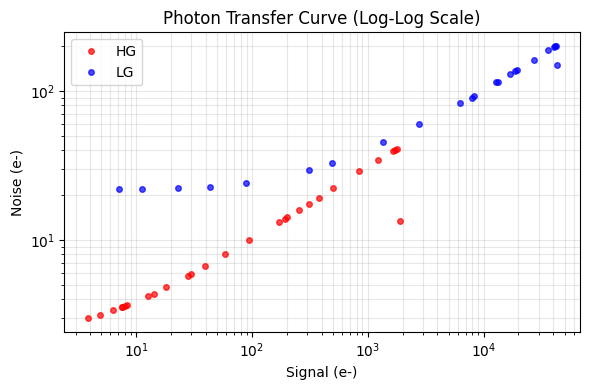

In [19]:
plt.figure(figsize=(6, 4))
plt.loglog(I_HG, sigma_HG, 'ro', alpha=0.7, label='HG', markersize=4)
plt.loglog(I_LG, sigma_LG, 'bo', alpha=0.7, label='LG', markersize=4)
plt.xlabel("Signal (e-)")
plt.ylabel("Noise (e-)")
plt.title("Photon Transfer Curve (Log-Log Scale)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()